<a href="https://colab.research.google.com/github/rezzz59/Sentimen-Analysis-Aplikasi-Grab/blob/main/grab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
%pip install google-play-scrapper

In [41]:
import sys
!{sys.executable} -m pip install google-play-scraper



In [42]:
import pandas as pd
from google_play_scraper import Sort, reviews

result, countinuation_token = reviews(
    'com.grabtaxi.passenger',
    lang = 'id',
    country = 'id',
    sort = Sort.NEWEST,
    count= 51000,
)

df = pd.DataFrame(result)

df = df[['content', 'score']]

df.to_csv('grab_review_raw.csv', index = False)

In [43]:
%pip install sastrawi

In [44]:
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

slang_dict = {
    "ga": "tidak", "gak": "tidak", "gakk": "tidak", "nggak": "tidak",
    "yg": "yang", "dr": "dari", "bgt": "banget", "kl": "kalau",
    "udh": "sudah", "udah": "sudah", "aja": "saja", "jd": "jadi",
    "tp": "tapi", "pake": "pakai", "sdh": "sudah", "aja": "saja",
    "dapet": "dapat", "ilang": "hilang", "lemot": "lambat", "gercep": "cepat",
}

def clean_text(text):
  text = text.lower()

  #menghapus link, mention dan tag
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = text = re.sub(r'@\w+|\#', '', text)

  #menghapus angka dan tanda bca
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\d+', '', text)

  #menghapus emoji
  text = text.encode('ascii', 'ignore').decode('ascii')

  #normalisasi kata & tokenizing
  words = text.split()
  cleaned_words = [slang_dict.get(w, w) for w in words]

  return " ".join(cleaned_words)

df['content_cleaned'] = df['content'].apply(clean_text)
df = df[df['content_cleaned'] != '']


In [45]:
def labeling(score):
  if score > 3:
    return "positif"
  if score <= 2:
    return 'negatif'
  else:
    return 'netral'

df['label'] = df['score'].apply(labeling)

In [46]:
df['label'].value_counts()

,count
label,
positif,38058
negatif,10539
netral,1610


In [47]:
from sklearn.utils import resample
target_samples = 8977

df_pos_bal = df[df['label'] == 'positif'].sample(target_samples, random_state=42)
df_neg_bal = df[df['label'] == 'negatif'].sample(target_samples, random_state=42)
df_neu_bal = resample(df[df['label'] == 'netral'], replace=True, n_samples=target_samples, random_state=42)

df_final = pd.concat([df_pos_bal, df_neg_bal, df_neu_bal])

In [48]:
df_final

,content,score,content_cleaned,label
29618,good,5,good,positif
15109,pengemudi ramah n bawa mobilnya enak,5,pengemudi ramah n bawa mobilnya enak,positif
49209,bagus,5,bagus,positif
34454,tingkatkan,4,tingkatkan,positif
15919,Baik,4,baik,positif
...,...,...,...,...
34578,Bagus,3,bagus,netral
30805,seharian daftar GK bisa bisa GK ada penjelasan...,3,seharian daftar gk bisa bisa gk ada penjelasan...,netral
47720,Saya kasih 3 karena saya baru coba aplikasi in...,3,saya kasih karena saya baru coba aplikasi ini,netral
35555,utamakan kebutuhan konsumen dlm fitur2 aplikasi,3,utamakan kebutuhan konsumen dlm fitur aplikasi,netral


In [49]:
df_final['label'].value_counts()

,count
label,
positif,8977
negatif,8977
netral,8977


In [50]:
df_final[['content_cleaned', 'score', 'label']]

,content_cleaned,score,label
29618,good,5,positif
15109,pengemudi ramah n bawa mobilnya enak,5,positif
49209,bagus,5,positif
34454,tingkatkan,4,positif
15919,baik,4,positif
...,...,...,...
34578,bagus,3,netral
30805,seharian daftar gk bisa bisa gk ada penjelasan...,3,netral
47720,saya kasih karena saya baru coba aplikasi ini,3,netral
35555,utamakan kebutuhan konsumen dlm fitur aplikasi,3,netral


In [51]:
import tensorflow as tf

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # Berhenti jika dalam 3 epoch tidak ada perbaikan
    restore_best_weights=True
)

# Callback untuk berhenti otomatis jika akurasi sudah memuaskan
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('val_accuracy') > 0.92):
            print("\nAkurasi sudah mencapai 92%")
            self.model.stop_training = True

callbacks = myCallback()

In [52]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense, Bidirectional, Dropout

In [53]:
df_final = df_final.reset_index(drop=True)
X = df_final['content_cleaned'].astype(str).values
y = pd.get_dummies(df_final['label']).astype(int).values

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size = 0.2, random_state=42)

tokenizer = Tokenizer(num_words=8000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train1)

X_train_seq1 = tokenizer.texts_to_sequences(X_train1)
X_test_seq1 = tokenizer.texts_to_sequences(X_test1)

#menyamakan panjang kalimat ada yang panjang dan pendek, sehingga disamakan menjadi 100 kata
X_train_pad1 = pad_sequences(X_train_seq1, maxlen=100, padding='post', truncating='post')
X_test_pad1 = pad_sequences(X_test_seq1, maxlen=100, padding='post', truncating='post')

#Skema 1
model1 = Sequential([
    Embedding(input_dim=8000, output_dim=128),
    SpatialDropout1D(0.3),
    LSTM(64, return_sequences=True),
    tf.keras.layers.GlobalMaxPooling1D(),
    Dense(3, activation='softmax')
])

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Latih Model 1
history1 = model1.fit(
    X_train_pad1, y_train1,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_pad1, y_test1),
    callbacks=[early_stop, callbacks],
    verbose=1
)

Epoch 1/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 75s 215ms/step - accuracy: 0.6912 - loss: 0.7080 - val_accuracy: 0.8034 - val_loss: 0.5285
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 70s 179ms/step - accuracy: 0.8287 - loss: 0.4634 - val_accuracy: 0.8443 - val_loss: 0.4510
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 60s 179ms/step - accuracy: 0.8706 - loss: 0.3637 - val_accuracy: 0.8535 - val_loss: 0.4279
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 81s 176ms/step - accuracy: 0.8892 - loss: 0.3143 - val_accuracy: 0.8626 - val_loss: 0.4101
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 60s 177ms/step - accuracy: 0.9001 - loss: 0.2841 - val_accuracy: 0.8600 - val_loss: 0.4189
Epoch 6/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 61s 180ms/step - accuracy: 0.9049 - loss: 0.2649 - val_accuracy: 0.8675 - val_loss: 0.4062
Epoch 7/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 67s 199ms/step - accuracy: 0.9134 - loss: 0.2395 - val_accuracy: 0.8682 - val_loss: 0.4083
Epoch 8/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 62s 185ms/step - accuracy: 0.9185 - loss: 0

In [54]:
X = df_final['content_cleaned'].astype(str).values
y = pd.get_dummies(df_final['label']).astype(int).values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size = 0.3, random_state=42)

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train2)

X_train_seq2 = tokenizer.texts_to_sequences(X_train2)
X_test_seq2 = tokenizer.texts_to_sequences(X_test2)

#menyamakan panjang kalimat ada yang panjang dan pendek, sehingga disamakan menjadi 100 kata
X_train_pad2 = pad_sequences(X_train_seq2, maxlen=100, padding='post', truncating='post')
X_test_pad2 = pad_sequences(X_test_seq2, maxlen=100, padding='post', truncating='post')

# Model Skema 2
model2 = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Latih Model 2
history2 = model2.fit(
    X_train_pad2, y_train2,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_pad2, y_test2),
    callbacks=[early_stop, callbacks],
    verbose=1
)

Epoch 1/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 106s 314ms/step - accuracy: 0.6868 - loss: 0.6968 - val_accuracy: 0.7972 - val_loss: 0.5309
Epoch 2/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 103s 349ms/step - accuracy: 0.8311 - loss: 0.4471 - val_accuracy: 0.8387 - val_loss: 0.4480
Epoch 3/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 130s 308ms/step - accuracy: 0.8734 - loss: 0.3491 - val_accuracy: 0.8548 - val_loss: 0.4228
Epoch 4/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 91s 309ms/step - accuracy: 0.8987 - loss: 0.2904 - val_accuracy: 0.8562 - val_loss: 0.4148
Epoch 5/20
295/295 ━━━━━━━━━━━━━━━━━━━━ 92s 312ms/step - accuracy: 0.9079 - loss: 0.2546 - val_accuracy: 0.8632 - val_loss: 0.4270


In [55]:
X = df_final['content_cleaned'].astype(str).values
y = pd.get_dummies(df_final['label']).astype(int).values

X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size = 0.2, random_state=42)

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train3)

X_train_seq3 = tokenizer.texts_to_sequences(X_train3)
X_test_seq3 = tokenizer.texts_to_sequences(X_test3)

#menyamakan panjang kalimat ada yang panjang dan pendek, sehingga disamakan menjadi 100 kata
X_train_pad3 = pad_sequences(X_train_seq3, maxlen=100, padding='post', truncating='post')
X_test_pad3 = pad_sequences(X_test_seq3, maxlen=100, padding='post', truncating='post')

#Skema 3
model3 = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Latih Model 3
history3 = model3.fit(
    X_train_pad3, y_train3,
    epochs=20,
    batch_size=64,
    validation_data=(X_test_pad3, y_test3 ),
    callbacks=[early_stop, callbacks],
    verbose=1
)

Epoch 1/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 183s 506ms/step - accuracy: 0.6606 - loss: 0.7453 - val_accuracy: 0.7873 - val_loss: 0.5600
Epoch 2/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 154s 457ms/step - accuracy: 0.8179 - loss: 0.4989 - val_accuracy: 0.8456 - val_loss: 0.4418
Epoch 3/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 153s 454ms/step - accuracy: 0.8695 - loss: 0.3762 - val_accuracy: 0.8547 - val_loss: 0.4130
Epoch 4/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 159s 473ms/step - accuracy: 0.8925 - loss: 0.3195 - val_accuracy: 0.8660 - val_loss: 0.4002
Epoch 5/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 194s 450ms/step - accuracy: 0.9056 - loss: 0.2789 - val_accuracy: 0.8699 - val_loss: 0.3887
Epoch 6/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 154s 456ms/step - accuracy: 0.9101 - loss: 0.2586 - val_accuracy: 0.8708 - val_loss: 0.4126
Epoch 7/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 154s 458ms/step - accuracy: 0.9161 - loss: 0.2425 - val_accuracy: 0.8667 - val_loss: 0.4400
Epoch 8/20
337/337 ━━━━━━━━━━━━━━━━━━━━ 164s 488ms/step - accuracy: 0.9184 -

In [56]:
df_final

,content,score,content_cleaned,label
0,good,5,good,positif
1,pengemudi ramah n bawa mobilnya enak,5,pengemudi ramah n bawa mobilnya enak,positif
2,bagus,5,bagus,positif
3,tingkatkan,4,tingkatkan,positif
4,Baik,4,baik,positif
...,...,...,...,...
26926,Bagus,3,bagus,netral
26927,seharian daftar GK bisa bisa GK ada penjelasan...,3,seharian daftar gk bisa bisa gk ada penjelasan...,netral
26928,Saya kasih 3 karena saya baru coba aplikasi in...,3,saya kasih karena saya baru coba aplikasi ini,netral
26929,utamakan kebutuhan konsumen dlm fitur2 aplikasi,3,utamakan kebutuhan konsumen dlm fitur aplikasi,netral


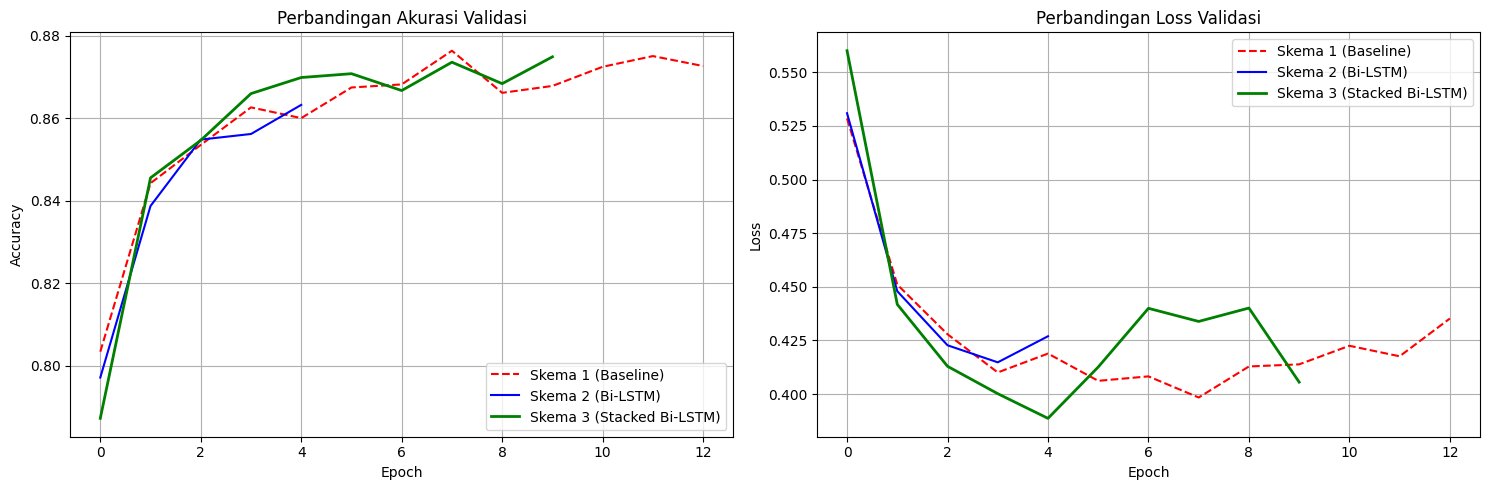

In [59]:
import matplotlib.pyplot as plt

# Membuat figure dengan 2 subplots
plt.figure(figsize=(15, 5))

# --- GRAFIK AKURASI ---
plt.subplot(1, 2, 1)
plt.plot(history1.history['val_accuracy'], label='Skema 1 (Baseline)', color='red', linestyle='--')
plt.plot(history2.history['val_accuracy'], label='Skema 2 (Bi-LSTM)', color='blue')
plt.plot(history3.history['val_accuracy'], label='Skema 3 (Stacked Bi-LSTM)', color='green', linewidth=2)
plt.title('Perbandingan Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- GRAFIK LOSS ---
plt.subplot(1, 2, 2)
plt.plot(history1.history['val_loss'], label='Skema 1 (Baseline)', color='red', linestyle='--')
plt.plot(history2.history['val_loss'], label='Skema 2 (Bi-LSTM)', color='blue')
plt.plot(history3.history['val_loss'], label='Skema 3 (Stacked Bi-LSTM)', color='green', linewidth=2)
plt.title('Perbandingan Loss Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
def predict_sentiment(text):
    # 1. Bersihkan teks
    cleaned = clean_text(text)
    # 2. Ubah ke sequence
    seq = tokenizer.texts_to_sequences([cleaned])
    # 3. Padding
    padded = pad_sequences(seq, maxlen=100, padding='post')
    # 4. Prediksi
    prediction = model.predict(padded)
    labels = ['Negatif', 'Netral', 'Positif'] # Sesuaikan urutan dummy variabelmu

    result = labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    return result, confidence

# Tes Kalimat
test_ulasan = "Drivernya sopan banget, tapi aplikasinya agak berat pas mau pesan makanan"
label, skor = predict_sentiment(test_ulasan)
print(f"Hasil: {label} ({skor:.2f}%)")